# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

---



- Nama: Irfan Maulana
- Email: irfanmau1605@gmail.com
- Id Dicoding: melonpan730

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os
import json

## Data Understanding

In [ ]:
# Load the dataset
df = pd.read_csv('data.csv', sep=';')
print("Data shape:", df.shape)
df.head()

Data shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [ ]:
# Cek missing values
print('Missing Values per Column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nAttrition Distribution (sebelum drop NA):')
print(df['Status'].value_counts(dropna=False))

Missing Values per Column:
Series([], dtype: int64)

Attrition Distribution (sebelum drop NA):
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
features = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Tuition_fees_up_to_date',
    'Debtor',
    'Scholarship_holder',
    'Admission_grade',
    'Age_at_enrollment',
    'Gender',
    'Status'
]

df = df[features]

In [ ]:
df.describe(include='all')

,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Tuition_fees_up_to_date,Debtor,Scholarship_holder,Admission_grade,Age_at_enrollment,Gender,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,4.706600,10.640822,4.435805,10.230206,0.880651,0.113698,0.248418,126.978119,23.265145,0.351718,NaN
std,3.094238,4.843663,3.014764,5.210808,0.324235,0.317480,0.432144,14.482001,7.587816,0.477560,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,17.000000,0.000000,NaN
25%,3.000000,11.000000,2.000000,10.750000,1.000000,0.000000,0.000000,117.900000,19.000000,0.000000,NaN
50%,5.000000,12.285714,5.000000,12.200000,1.000000,0.000000,0.000000,126.100000,20.000000,0.000000,NaN
75%,6.000000,13.400000,6.000000,13.333333,1.000000,0.000000,0.000000,134.800000,25.000000,1.000000,NaN


## Exploratory Data Analysis

/tmp/ipykernel_7073/1768392174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


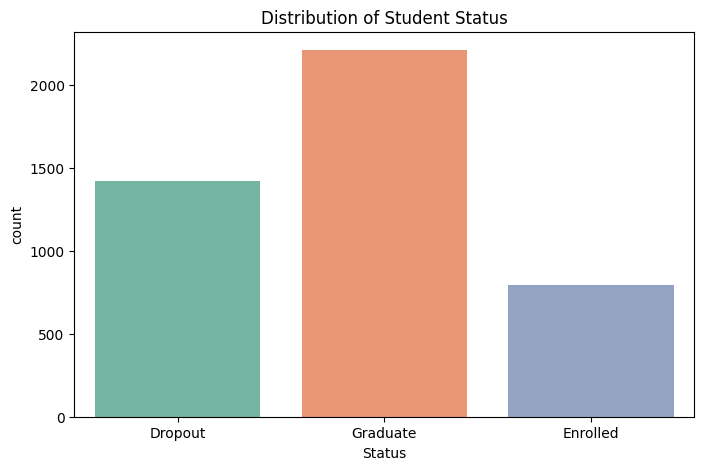

In [ ]:
# EDA: Distribusi Status Siswa
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribution of Student Status')
plt.show()

/tmp/ipykernel_7073/2838519211.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Age_at_enrollment', palette='Set2')


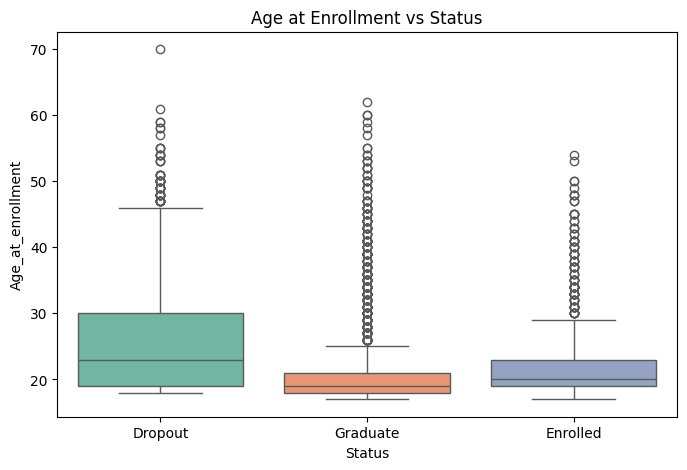

In [ ]:
# EDA: Age at Enrollment vs Status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Status', y='Age_at_enrollment', palette='Set2')
plt.title('Age at Enrollment vs Status')
plt.show()

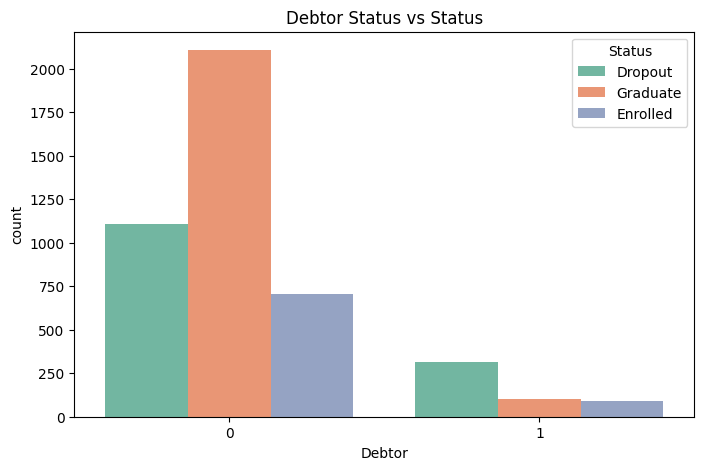

In [ ]:
# EDA: Debtor vs Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Debtor', hue='Status', palette='Set2')
plt.title('Debtor Status vs Status')
plt.show()

## Data Preprocessing

In [ ]:
# Encoding Target Variable
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Status_Encoded'] = df['Status'].map(target_mapping)

X = df.drop(['Status', 'Status_Encoded'], axis=1)
y = df['Status_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3539, 10)
Testing data shape: (885, 10)


/tmp/ipykernel_7073/2636251067.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Status_Encoded'] = df['Status'].map(target_mapping)


## Modeling

In [ ]:
# Hyperparameter Tuning dengan GridSearchCV
# Strategi anti-overfitting: max_depth sangat dangkal, min_samples tinggi
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4, 5],            # Sangat dangkal agar tidak menghafal data
    'min_samples_split': [30, 50, 80], # Butuh banyak sampel untuk split
    'min_samples_leaf': [20, 30, 50],  # Setiap daun harus punya banyak sampel
    'max_features': ['sqrt'],          # Batasi jumlah fitur per split
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

print("Memulai pencarian hyperparameter terbaik...")
grid_search.fit(X_train, y_train)

rf_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)
print(f"Best CV Score (Validation): {grid_search.best_score_:.4f}")

# Bandingkan train vs validation score dari CV
best_idx = grid_search.best_index_
mean_train = grid_search.cv_results_['mean_train_score'][best_idx]
mean_val = grid_search.cv_results_['mean_test_score'][best_idx]
print(f"\nMean Train Score (CV): {mean_train:.4f}")
print(f"Mean Validation Score (CV): {mean_val:.4f}")
print(f"Gap (Train - Val): {mean_train - mean_val:.4f}")

if (mean_train - mean_val) < 0.05:
    print("\nGap kecil -> Model TIDAK overfitting pada cross-validation!")
else:
    print("\nGap masih cukup besar.")

Memulai pencarian hyperparameter terbaik...

Best Parameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 30, 'n_estimators': 150}
Best CV Score (Validation): 0.7186

Mean Train Score (CV): 0.7229
Mean Validation Score (CV): 0.7186
Gap (Train - Val): 0.0044

Gap kecil -> Model TIDAK overfitting pada cross-validation!


## Evaluation

In [ ]:
# Evaluasi Final: Train vs Test Accuracy
y_train_pred = rf_model.predict(X_train)
y_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

In [ ]:
# Classification Report Train Data
print(classification_report(y_train, y_train_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))


              precision    recall  f1-score   support

     Dropout       0.84      0.67      0.74      1137
    Enrolled       0.42      0.56      0.48       635
    Graduate       0.81      0.81      0.81      1767

    accuracy                           0.72      3539
   macro avg       0.69      0.68      0.68      3539
weighted avg       0.75      0.72      0.73      3539



In [ ]:
# Classification Report Test Data
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))


              precision    recall  f1-score   support

     Dropout       0.83      0.64      0.72       284
    Enrolled       0.39      0.57      0.46       159
    Graduate       0.82      0.80      0.81       442

    accuracy                           0.71       885
   macro avg       0.68      0.67      0.66       885
weighted avg       0.74      0.71      0.72       885



EVALUASI PERFORMA MODEL (Best Estimator)
Training Accuracy : 0.7220
Testing Accuracy  : 0.7051
Gap (Overfit Indicator): 0.0169

Kesimpulan: Model tergolong GOOD FIT!


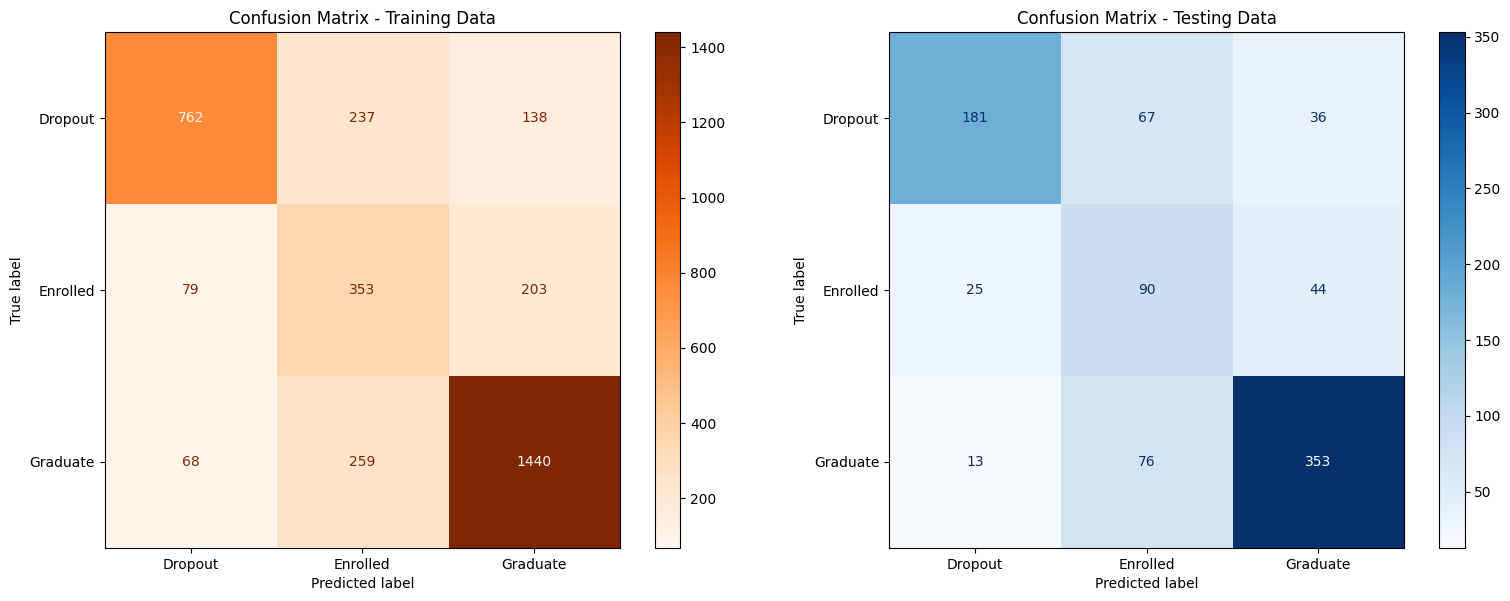

In [ ]:
print("=" * 50)
print("EVALUASI PERFORMA MODEL (Best Estimator)")
print("=" * 50)
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Gap (Overfit Indicator): {train_accuracy - test_accuracy:.4f}")
print("=" * 50)

gap = train_accuracy - test_accuracy
if gap > 0.10:
    print("\nKesimpulan: Model terindikasi OVERFITTING.")
elif gap > 0.05:
    print("\nKesimpulan: Model SEDIKIT overfitting, masih dalam toleransi.")
elif train_accuracy < 0.60:
    print("\nKesimpulan: Model terindikasi UNDERFITTING.")
else:
    print("\nKesimpulan: Model tergolong GOOD FIT!")

# Confusion Matrix: Train vs Test side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
    display_labels=['Dropout', 'Enrolled', 'Graduate'], cmap='Oranges', ax=axes[0])
axes[0].set_title('Confusion Matrix - Training Data')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Dropout', 'Enrolled', 'Graduate'], cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Testing Data')

plt.tight_layout()
plt.show()

## Saving the Model

In [ ]:
# Simpan model terbaik
os.makedirs('model', exist_ok=True)
joblib.dump(rf_model, 'model/rf_model.joblib')

with open('model/features.json', 'w') as f:
    json.dump(list(X.columns), f)

print("Model dan features berhasil disimpan.")
print("Best model params:", rf_model.get_params())

Model dan features berhasil disimpan.
Best model params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 20, 'min_samples_split': 30, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 150, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
